# 대만 기업 월간 매출 — 수집 · 예측 · 시각화 (`taiwan_revenue_forecast_v1`)

**데이터 원천:** Compal Electronics IR 페이지 (https://www.compal.com/en-us/investor-relations/financial-release/)
- 단위: **천 대만달러 (NT$ thousand)** — IR 페이지 표기 기준. *DB에도 원 단위 그대로 저장 (단위 변환 없음)*
- 크롤러는 업로드된 `Compal_revenue.ipynb`의 함수를 **수정 없이 그대로** 사용

### 파이프라인 (단일 노트북, 위에서 아래로 실행)
1. 경로 설정 (노트북/데스크탑 공용) → 모듈 import → DB 연결
2. 월간 매출 크롤링 (기존 함수 그대로)
3. **매출 흐름 시각화** — 월간 매출 추이 + YoY (신규)
4. 월간 시계열 구성 → SARIMA / ETS / Theta / Ensemble **12개월 예측** (기존 공용 모듈 사용, 신규)
5. 예측 결과를 **`taiwan_company_revenue_forecast`** 테이블에 `forecast_date`(예측 수행일) 구분값으로 저장 (신규)
   - PK: `(forecast_date, ticker, target_date, model)` — 티커 기반이라 다른 대만 기업 추가 시 같은 테이블 공유
6. **예측 빈티지 비교 시각화** — 예측일별 예측 경로 변화를 실적 위에 겹쳐 비교 (신규)

> 예측 저장은 한국/수출 파이프라인과 동일 원칙: 실적과 예측을 분리하고, `forecast_date`를 PK에 포함해
> 예측 시점별 이력이 자연스럽게 쌓이는 구조. 같은 날 재실행하면 같은 빈티지에 덮어씀(의도된 동작).

## 1. 사용자 입력 변수 (이 셀만 수정)

In [1]:
# ==================== 사용자 입력 변수 (필요 시 여기만 수정) ====================

# --- 대상 기업 ---------------------------------------------------------------
TICKER       = "2324"     # 대만 증시 티커 (Compal Electronics = 2324.TW)
COMPANY_NAME = "Compal"   # 회사명 (DB 저장용)

# --- 크롤링 기간 -------------------------------------------------------------
START_YEAR = 2012
END_YEAR   = None         # None이면 실행 시점의 올해까지 자동

# --- DB 설정 ----------------------------------------------------------------
FORECAST_TABLE = "taiwan_company_revenue_forecast"   # 대만 기업 매출 예측 테이블 (영문)

# --- 예측 설정 --------------------------------------------------------------
RUN_FORECAST = True   # False면 수집/시각화만 수행
HORIZON      = 12     # 예측 개월 수
SEASONAL_M   = 12     # 월간 계절주기
MIN_OBS      = 36     # 예측에 필요한 최소 관측 개월 수 (3년)

# --- 시각화 설정 ------------------------------------------------------------
PLOT_YEARS_BACK = 5   # 과거+전망 차트에 표시할 과거 연수

## 2. 경로 설정 (노트북 / 데스크탑 공용)
`DATA` 폴더를 자동 탐색해 프로젝트 루트와 함께 `sys.path`에 추가하고, 실패 시 두 PC의 고정 경로로 fallback합니다.

In [2]:
import sys
import os
from pathlib import Path

# 두 PC의 알려진 DATA 폴더 경로 (fallback용)
KNOWN_DATA_PATHS = [
    r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast\DATA",
    r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA",
]

def setup_universal_paths():
    """어떤 PC에서도 작동하는 범용 경로 설정: DATA 폴더 자동 탐색 + 고정 경로 fallback"""
    current = Path.cwd()
    for parent in [current, *current.parents]:
        data_folder = parent / "DATA"
        if data_folder.exists():
            for p in (str(parent), str(data_folder)):
                if p not in sys.path:
                    sys.path.insert(0, p)
            print(f"[경로 설정] 자동 탐색 성공 | 프로젝트 루트: {parent}")
            print(f"[경로 설정] DATA 폴더: {data_folder}")
            return str(data_folder)
    for dp in KNOWN_DATA_PATHS:
        if os.path.exists(dp):
            root = str(Path(dp).parent)
            for p in (root, dp):
                if p not in sys.path:
                    sys.path.insert(0, p)
            print(f"[경로 설정] 고정 경로 사용 | 프로젝트 루트: {root}")
            print(f"[경로 설정] DATA 폴더: {dp}")
            return dp
    raise FileNotFoundError(
        f"DATA 폴더를 찾을 수 없습니다.\n현재 위치: {current}\n"
        f"상위 폴더에 DATA 폴더가 있는지, 또는 KNOWN_DATA_PATHS의 경로가 맞는지 확인하세요."
    )

DATA_PATH = setup_universal_paths()

[경로 설정] 자동 탐색 성공 | 프로젝트 루트: C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast
[경로 설정] DATA 폴더: C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast\DATA


## 3. Import 및 DB 연결

In [3]:
import logging
import warnings

import requests
from bs4 import BeautifulSoup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)

# 한글 폰트 (Windows)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ── 기존 공용 함수 (수정 금지 모듈) ─────────────────────────────────────────
#    ※ 와일드카드 import를 "먼저" 수행 (내부 `import datetime` 등이
#      동명 클래스를 모듈로 덮어쓰는 shadowing 방지 — 수출 노트북 v7에서 확인된 이슈)
from DATA.stock_invest_function import *  # get_db_host 등
from universal_ts_forecast_function_v2 import (
    forecast_sarima,
    forecast_ets,
    forecast_theta,
)

# ── 이 노트북이 사용하는 핵심 이름들을 star import "이후"에 확정 import ──────
import time
from datetime import date, datetime, timedelta
from calendar import monthrange
from sqlalchemy import create_engine, text

DB_INFO = {
    "host": get_db_host(),
    "port": 3307,
    "user": "stox7412",
    "password": "Apt106503!~",
    "database": "investar",
}

def get_engine_from_info(db_info: dict):
    url = (f"mysql+pymysql://{db_info['user']}:{db_info['password']}"
           f"@{db_info['host']}:{db_info['port']}/{db_info['database']}?charset=utf8mb4")
    return create_engine(url, pool_recycle=3600)

engine = get_engine_from_info(DB_INFO)
with engine.connect() as conn:
    conn.execute(text("SELECT 1"))
print("DB 연결 성공")

DB 연결 성공


## 4. 월간 매출 크롤러 (업로드 원본 그대로 — 수정 없음)

In [4]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from datetime import datetime
import time

def crawl_compal_monthly_sales(start_year=2012, end_year=2025):
    """
    컴팔(Compal Electronics) 월간 매출 데이터 크롤링

    Parameters:
    start_year: 시작 연도
    end_year: 종료 연도

    Returns:
    DataFrame: 월간 매출 데이터
    """

    url = "https://www.compal.com/en-us/investor-relations/financial-release/"

    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
    }

    try:
        response = requests.get(url, headers=headers, timeout=30)
        response.raise_for_status()
        response.encoding = 'utf-8'

        soup = BeautifulSoup(response.text, 'html.parser')

        all_data = []

        for year in range(start_year, end_year + 1):
            # data-sale 속성으로 테이블 찾기
            table = soup.find('table', {'data-sale': str(year)})

            if not table:
                print(f"연도 {year} 데이터를 찾을 수 없습니다.")
                continue

            # thead에서 컬럼 정보 추출
            thead = table.find('thead')
            if not thead:
                continue

            header_cells = thead.find_all('td')
            if len(header_cells) < 5:
                continue

            current_year = header_cells[1].get_text(strip=True)
            prev_year = header_cells[2].get_text(strip=True)

            # tbody에서 데이터 추출
            tbody = table.find('tbody')
            if not tbody:
                continue

            rows = tbody.find_all('tr')

            for row in rows:
                cells = row.find_all('td')

                if not cells or len(cells) < 5:
                    continue

                month_text = cells[0].get_text(strip=True)

                # 분기(Q1, Q2, etc)와 연간(Annual) 데이터는 건너뛰기
                if month_text in ['1Q', '2Q', '3Q', '4Q', 'Annual']:
                    continue

                # 월 이름을 숫자로 변환
                month_mapping = {
                    'January': 1, 'February': 2, 'March': 3, 'April': 4,
                    'May': 5, 'June': 6, 'July': 7, 'August': 8,
                    'September': 9, 'October': 10, 'November': 11, 'December': 12
                }

                month_num = month_mapping.get(month_text)

                if not month_num:
                    continue

                # 데이터 추출
                try:
                    current_sales = cells[1].get_text(strip=True).replace(',', '')
                    prev_sales = cells[2].get_text(strip=True).replace(',', '')
                    mom = cells[3].get_text(strip=True).replace('%', '')
                    yoy = cells[4].get_text(strip=True).replace('%', '')

                    # 빈 값이 아닌 경우만 저장
                    if current_sales and current_sales != '':
                        data_dict = {
                            'year': year,
                            'month': month_num,
                            'date': f"{year}-{month_num:02d}",
                            'current_year': current_year,
                            'current_sales': float(current_sales) if current_sales else None,
                            'prev_year': prev_year,
                            'prev_sales': float(prev_sales) if prev_sales else None,
                            'mom': float(mom) if mom and mom != '--' else None,
                            'yoy': float(yoy) if yoy and yoy != '--' else None
                        }

                        all_data.append(data_dict)

                except (ValueError, IndexError) as e:
                    print(f"연도 {year}, 월 {month_text} 데이터 파싱 오류: {e}")
                    continue

            print(f"연도 {year} 데이터 수집 완료")
            time.sleep(0.5)

        if not all_data:
            print("크롤링된 데이터가 없습니다.")
            return pd.DataFrame()

        df = pd.DataFrame(all_data)

        # 날짜 순으로 정렬
        df = df.sort_values(['year', 'month']).reset_index(drop=True)

        print(f"\n총 {len(df)}개의 데이터를 수집했습니다.")
        print(f"기간: {df['date'].min()} ~ {df['date'].max()}")

        return df

    except requests.exceptions.RequestException as e:
        print(f"데이터 요청 중 오류 발생: {e}")
        return pd.DataFrame()
    except Exception as e:
        print(f"예상치 못한 오류 발생: {e}")
        return pd.DataFrame()


def save_to_excel(df, filename='compal_monthly_sales.xlsx'):
    """
    데이터를 Excel 파일로 저장
    """
    if df.empty:
        print("저장할 데이터가 없습니다.")
        return

    try:
        with pd.ExcelWriter(filename, engine='openpyxl') as writer:
            df.to_excel(writer, sheet_name='Monthly Sales', index=False)

            # 워크시트 가져오기
            worksheet = writer.sheets['Monthly Sales']

            # 컬럼 너비 자동 조정
            for column in worksheet.columns:
                max_length = 0
                column_letter = column[0].column_letter

                for cell in column:
                    try:
                        if len(str(cell.value)) > max_length:
                            max_length = len(str(cell.value))
                    except:
                        pass

                adjusted_width = min(max_length + 2, 50)
                worksheet.column_dimensions[column_letter].width = adjusted_width

        print(f"\n데이터가 '{filename}' 파일로 저장되었습니다.")

    except Exception as e:
        print(f"Excel 저장 중 오류 발생: {e}")


def get_quarterly_summary(df):
    """
    분기별 요약 데이터 생성
    """
    if df.empty:
        return pd.DataFrame()

    # 분기 계산
    df['quarter'] = df['month'].apply(lambda x: f"Q{(x-1)//3 + 1}")

    # 분기별 집계
    quarterly = df.groupby(['year', 'quarter']).agg({
        'current_sales': 'sum',
        'prev_sales': 'sum'
    }).reset_index()

    # YoY 계산
    quarterly['yoy'] = ((quarterly['current_sales'] - quarterly['prev_sales']) /
                        quarterly['prev_sales'] * 100).round(2)

    return quarterly


# def main():
#     """
#     메인 실행 함수
#     """
#     print("컴팔(Compal Electronics) 월간 매출 데이터 크롤링 시작...")
#     print("=" * 60)
#
#     # 데이터 크롤링 (2012년부터 2025년까지)
#     df = crawl_compal_monthly_sales(start_year=2012, end_year=2025)
#
#     if not df.empty:
#         # 데이터 미리보기
#         print("\n" + "=" * 60)
#         print("데이터 미리보기 (최근 10개):")
#         print(df.tail(10).to_string())
#
#         # 기본 통계
#         print("\n" + "=" * 60)
#         print("기본 통계:")
#         print(df[['current_sales', 'mom', 'yoy']].describe())
#
#         # 분기별 요약
#         print("\n" + "=" * 60)
#         print("최근 분기별 요약:")
#         quarterly = get_quarterly_summary(df)
#         print(quarterly.tail(8).to_string())
#
#         # Excel 저장
#         save_to_excel(df, 'compal_monthly_sales.xlsx')
#
#         # 분기별 요약도 별도 시트로 저장
#         try:
#             with pd.ExcelWriter('compal_monthly_sales.xlsx',
#                               mode='a',
#                               engine='openpyxl',
#                               if_sheet_exists='replace') as writer:
#                 quarterly.to_excel(writer, sheet_name='Quarterly Summary', index=False)
#             print("분기별 요약 데이터도 저장되었습니다.")
#         except:
#             pass
#
#         return df
#     else:
#         print("크롤링 실패")
#         return None
#
#
# if __name__ == "__main__":
#     df = main()

## 5. 수집 실행

In [5]:
_end_year = END_YEAR if END_YEAR is not None else date.today().year
df = crawl_compal_monthly_sales(start_year=START_YEAR, end_year=_end_year)

if df.empty:
    raise RuntimeError("크롤링 데이터가 없습니다. 사이트 구조 변경 또는 네트워크 상태를 확인하세요.")

print(df.tail(13).to_string())

연도 2012 데이터 수집 완료
연도 2013 데이터 수집 완료
연도 2014 데이터 수집 완료
연도 2015 데이터 수집 완료
연도 2016 데이터 수집 완료
연도 2017 데이터 수집 완료
연도 2018 데이터 수집 완료
연도 2019 데이터 수집 완료
연도 2020 데이터 수집 완료
연도 2021 데이터 수집 완료
연도 2022 데이터 수집 완료
연도 2023 데이터 수집 완료
연도 2024 데이터 수집 완료
연도 2025 데이터 수집 완료
연도 2026 데이터 수집 완료

총 174개의 데이터를 수집했습니다.
기간: 2012-01 ~ 2026-06
     year  month     date current_year  current_sales prev_year  prev_sales   mom   yoy
161  2025      6  2025-06         2025        60520.0      2024     82657.0   5.0 -26.8
162  2025      7  2025-07         2025        58591.0      2024     76440.0  -3.2 -23.4
163  2025      8  2025-08         2025        58809.0      2024     84111.0   0.4 -30.1
164  2025      9  2025-09         2025        69720.0      2024     83766.0  18.6 -16.8
165  2025     10  2025-10         2025        61920.0      2024     85452.0 -11.2 -27.5
166  2025     11  2025-11         2025        62968.0      2024     79666.0   1.7 -21.0
167  2025     12  2025-12         2025        65964.0      2024     64

## 6. 매출 흐름 시각화 (실적)
월간 매출 추이(선) + YoY 증감률(막대)로 매출 흐름을 확인합니다.

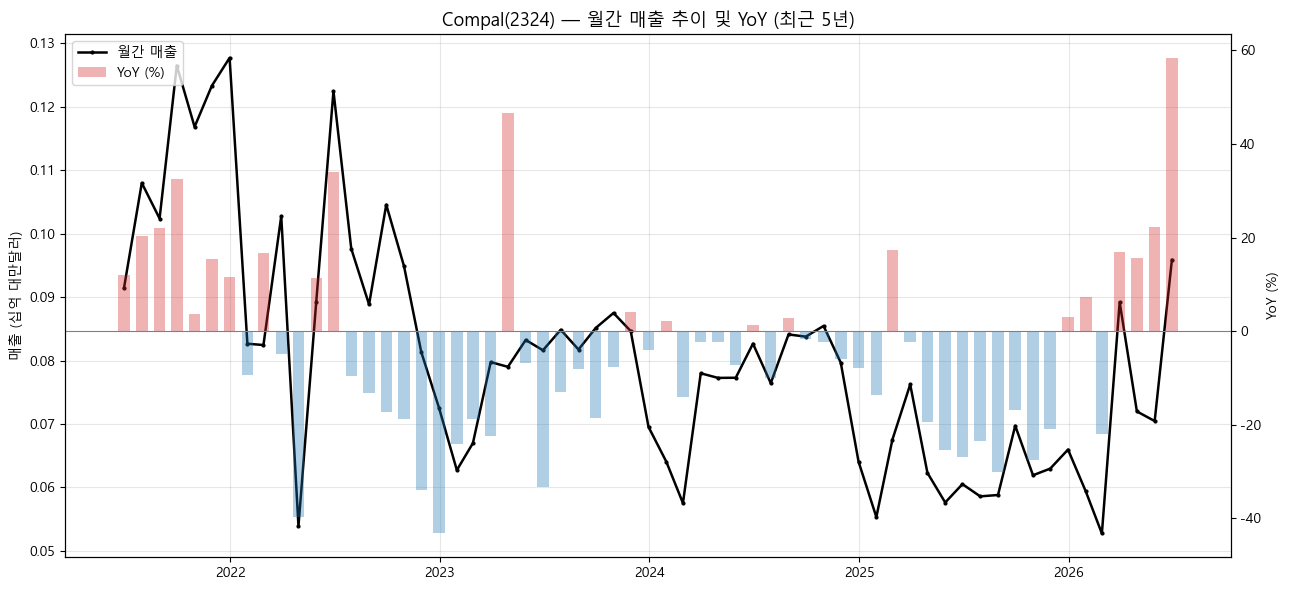

In [6]:
# pandas 버전별 월말 주기 표기 자동 감지: 1.x='M', 2.2+='ME'
try:
    pd.tseries.frequencies.to_offset("M")
    MONTH_END_FREQ = "M"
except ValueError:
    MONTH_END_FREQ = "ME"

def build_monthly_series(df_in: pd.DataFrame) -> pd.Series:
    """크롤링 결과 → 월말 DatetimeIndex의 매출 pd.Series (천 대만달러)"""
    d = df_in.dropna(subset=["current_sales"]).copy()
    idx = pd.to_datetime(d["date"], format="%Y-%m") + pd.offsets.MonthEnd(0)
    s = pd.Series(d["current_sales"].values.astype(float), index=pd.DatetimeIndex(idx))
    s = s[~s.index.duplicated(keep="last")].sort_index()
    s = s.asfreq(MONTH_END_FREQ)
    n_na = int(s.isna().sum())
    if n_na:
        print(f"[주의] 결측월 {n_na}개 → 선형 보간")
        s = s.interpolate(limit_direction="both")
    return s

def plot_revenue_history(df_in: pd.DataFrame, years_back: int = PLOT_YEARS_BACK):
    """월간 매출 추이 + YoY 증감률"""
    s = build_monthly_series(df_in)
    yoy = (s / s.shift(12) - 1.0) * 100
    cut = s.index[-1] - pd.DateOffset(years=years_back)
    s_p, yoy_p = s[s.index >= cut], yoy[yoy.index >= cut]

    fig, ax1 = plt.subplots(figsize=(13, 6))
    ax2 = ax1.twinx()
    colors = ["tab:red" if v >= 0 else "tab:blue" for v in yoy_p.fillna(0)]
    ax2.bar(yoy_p.index, yoy_p.values, width=20, color=colors, alpha=0.35, label="YoY (%)")
    ax2.axhline(0, color="gray", lw=0.8)
    ax1.plot(s_p.index, s_p.values / 1e6, color="black", lw=1.8, marker=".", ms=4,
             label="월간 매출", zorder=5)
    ax1.set_ylabel("매출 (십억 대만달러)")   # 천 NTD / 1e6 = 십억 NTD
    ax2.set_ylabel("YoY (%)")
    ax1.set_title(f"{COMPANY_NAME}({TICKER}) — 월간 매출 추이 및 YoY (최근 {years_back}년)", fontsize=13)
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper left")
    ax1.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_revenue_history(df)

## 7. 12개월 시계열 예측 (SARIMA / ETS / Theta / Ensemble)
공용 모듈 `universal_ts_forecast_function_v2` 그대로 사용 (수정 금지). Ensemble = 성공 모델 단순 평균.

In [7]:
def run_revenue_forecast(df_in: pd.DataFrame, horizon: int = HORIZON, m: int = SEASONAL_M) -> Optional[pd.DataFrame]:
    """
    월간 매출 시계열에 대해 SARIMA/ETS/Theta 예측 후 Ensemble 계산.
    반환: [ticker, company_name, target_date, model, revenue] long DataFrame
    """
    s = build_monthly_series(df_in)
    if len(s) < MIN_OBS:
        print(f"[스킵] 관측 {len(s)}개월 < MIN_OBS({MIN_OBS})")
        return None

    future_idx = pd.date_range(s.index[-1] + pd.offsets.MonthEnd(1), periods=horizon, freq=MONTH_END_FREQ)
    results = {}

    # ※ 함수 시그니처 규약: SARIMA는 seasonal_period=m, ETS/Theta는 m=m, 반환 dict "forecast"에서 배열 추출
    try:
        r = forecast_sarima(s, horizon, seasonal_period=m)
        results["SARIMA"] = np.asarray(r["forecast"], dtype=float)
    except Exception as e:
        print(f"[실패] SARIMA: {e}")
    try:
        r = forecast_ets(s, horizon, m=m)
        results["ETS"] = np.asarray(r["forecast"], dtype=float)
    except Exception as e:
        print(f"[실패] ETS: {e}")
    try:
        r = forecast_theta(s, horizon, m=m)
        results["THETA"] = np.asarray(r["forecast"], dtype=float)
    except Exception as e:
        print(f"[실패] THETA: {e}")

    if not results:
        print("[스킵] 모든 모델 실패")
        return None
    results["ENSEMBLE"] = np.mean(np.vstack(list(results.values())), axis=0)

    rows = []
    for model, arr in results.items():
        for dt_, v in zip(future_idx, arr):
            rows.append({"ticker": TICKER, "company_name": COMPANY_NAME,
                         "target_date": dt_.date(), "model": model,
                         "revenue": int(round(float(v)))})
    print(f"[완료] {COMPANY_NAME}({TICKER}): 모델 {sorted(results.keys())} | "
          f"예측 {future_idx[0].date()} ~ {future_idx[-1].date()}")
    return pd.DataFrame(rows)

## 8. 예측 결과 저장 — `taiwan_company_revenue_forecast` (`forecast_date` 구분값)

In [8]:
DDL_FORECAST = f"""
CREATE TABLE IF NOT EXISTS {FORECAST_TABLE} (
    forecast_date DATE        NOT NULL COMMENT '예측 수행일 (빈티지 구분값)',
    ticker        VARCHAR(10) NOT NULL COMMENT '대만 증시 티커 (예: 2324)',
    company_name  VARCHAR(50) NOT NULL,
    target_date   DATE        NOT NULL COMMENT '예측 대상 월 (월말)',
    model         VARCHAR(20) NOT NULL COMMENT 'SARIMA/ETS/THETA/ENSEMBLE',
    revenue       BIGINT      NOT NULL COMMENT '예측 월간 매출 (천 대만달러, 원본 단위 그대로)',
    created_at    DATETIME    NOT NULL,
    PRIMARY KEY (forecast_date, ticker, target_date, model)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4
"""

UPSERT_FORECAST = text(f"""
INSERT INTO {FORECAST_TABLE}
    (forecast_date, ticker, company_name, target_date, model, revenue, created_at)
VALUES
    (:forecast_date, :ticker, :company_name, :target_date, :model, :revenue, :created_at)
ON DUPLICATE KEY UPDATE
    revenue = VALUES(revenue),
    company_name = VALUES(company_name),
    created_at = VALUES(created_at)
""")

def save_forecast(fdf: pd.DataFrame):
    forecast_date = date.today()   # 같은 날 재실행 시 같은 빈티지에 덮어씀 (의도된 동작)
    rows = fdf.to_dict("records")
    now = datetime.now()
    for r in rows:
        r["forecast_date"] = forecast_date
        r["created_at"] = now
    with engine.begin() as conn:
        conn.execute(text(DDL_FORECAST))
        conn.execute(UPSERT_FORECAST, rows)
    print(f"예측 저장 완료: {len(rows):,}행 → {FORECAST_TABLE} (forecast_date={forecast_date})")

if RUN_FORECAST:
    forecast_df = run_revenue_forecast(df)
    if forecast_df is not None:
        save_forecast(forecast_df)
else:
    print("RUN_FORECAST=False — 예측 단계 생략")

[메모리] forecast_sarima 실행 전: 435.22 MB
[메모리] find_best_sarima_params 실행 전: 435.23 MB


2026-07-15 13:05:05,764 - WARNING - From C:\Users\Hoyoung_Park\PyCharmMiscProject\.venv1\lib\site-packages\keras\src\backend\common\global_state.py:82: The name tf.reset_default_graph is deprecated. Please use tf.compat.v1.reset_default_graph instead.



[메모리] find_best_sarima_params 실행 후: 446.25 MB (변화: +11.03 MB)
[메모리] forecast_sarima 실행 후: 446.38 MB (변화: +11.16 MB)
[메모리] forecast_ets 실행 전: 446.38 MB
[메모리] forecast_ets 실행 후: 446.52 MB (변화: +0.14 MB)
[메모리] forecast_theta 실행 전: 446.52 MB
[메모리] forecast_theta 실행 후: 446.70 MB (변화: +0.18 MB)
[완료] Compal(2324): 모델 ['ENSEMBLE', 'ETS', 'SARIMA', 'THETA'] | 예측 2026-07-31 ~ 2027-06-30
예측 저장 완료: 48행 → taiwan_company_revenue_forecast (forecast_date=2026-07-15)


## 9. 시각화 — 과거 + 향후 전망 / 예측 빈티지 비교
- `plot_history_and_forecast()`: 과거 실적 + 최신 예측 12개월 (Ensemble 굵은 선 + 개별 모델 점선)
- `plot_forecast_vintages()`: **예측일(`forecast_date`)별 예측 경로의 변화**를 실적 위에 겹쳐 기간별 비교

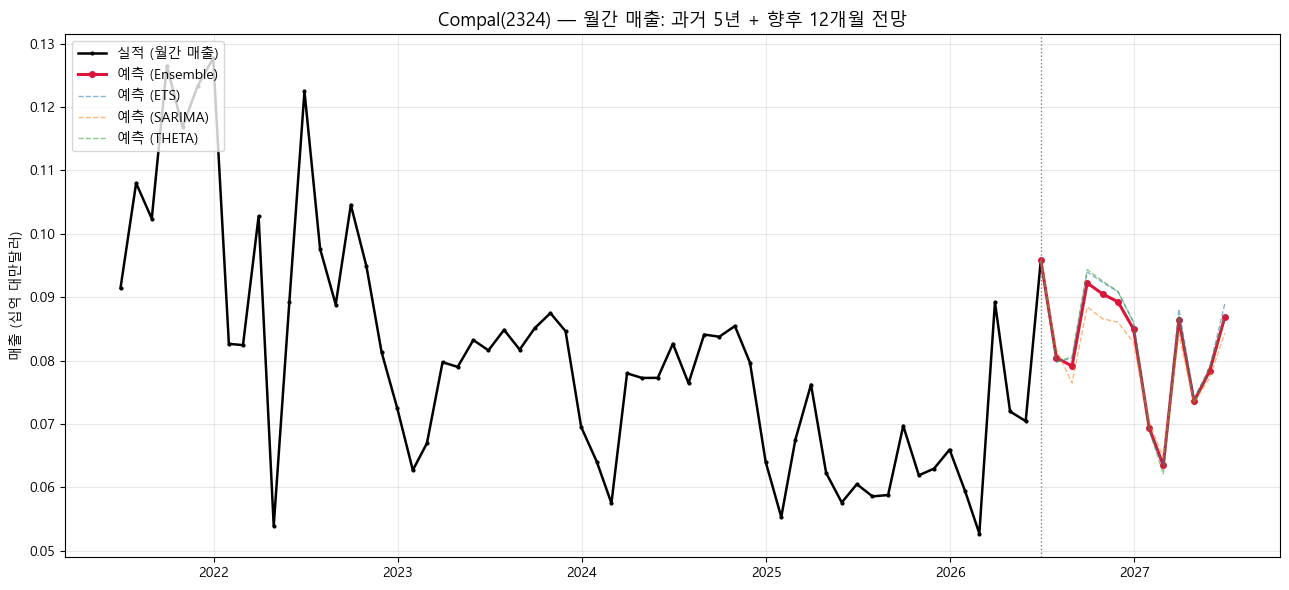

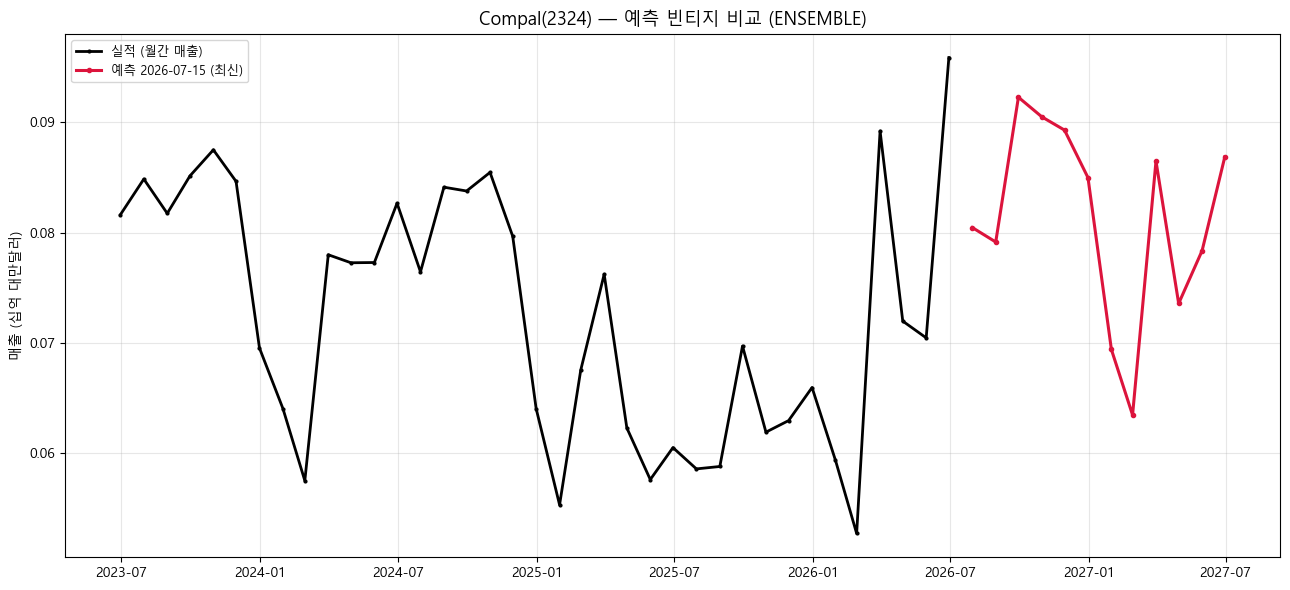

In [9]:
def plot_history_and_forecast(df_in: pd.DataFrame, years_back: int = PLOT_YEARS_BACK,
                              show_models: bool = True):
    """과거 실적 + 최신 예측 (DB의 최신 forecast_date 빈티지)"""
    s = build_monthly_series(df_in)
    s_plot = s[s.index >= s.index[-1] - pd.DateOffset(years=years_back)]

    fq = text(f"""
        SELECT target_date, model, revenue
        FROM {FORECAST_TABLE}
        WHERE ticker = :tk
          AND forecast_date = (SELECT MAX(forecast_date) FROM {FORECAST_TABLE} WHERE ticker = :tk)
        ORDER BY target_date
    """)
    fdf = pd.read_sql(fq, engine, params={"tk": TICKER})

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.plot(s_plot.index, s_plot.values / 1e6, color="black", lw=1.8, marker=".", ms=4,
            label="실적 (월간 매출)")

    if not fdf.empty:
        fdf["target_date"] = pd.to_datetime(fdf["target_date"])
        bridge_x, bridge_y = s.index[-1], s.values[-1] / 1e6
        for model, g in fdf.groupby("model"):
            x = [bridge_x] + list(g["target_date"])
            y = [bridge_y] + list(g["revenue"] / 1e6)
            if model == "ENSEMBLE":
                ax.plot(x, y, color="crimson", lw=2.2, marker="o", ms=4, label="예측 (Ensemble)")
            elif show_models:
                ax.plot(x, y, ls="--", lw=1.0, alpha=0.55, label=f"예측 ({model})")
        ax.axvline(s.index[-1], color="gray", ls=":", lw=1)
    else:
        print("저장된 예측 없음 — 실적만 표시")

    ax.set_title(f"{COMPANY_NAME}({TICKER}) — 월간 매출: 과거 {years_back}년 + 향후 {HORIZON}개월 전망",
                 fontsize=13)
    ax.set_ylabel("매출 (십억 대만달러)")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_forecast_vintages(df_in: pd.DataFrame, n_vintages: int = 6,
                           years_back: int = 3, model: str = "ENSEMBLE"):
    """예측일별 예측 경로 변화 비교 (실적 오버레이) — 최근 n개 빈티지"""
    s = build_monthly_series(df_in)
    s_plot = s[s.index >= s.index[-1] - pd.DateOffset(years=years_back)]

    vq = text(f"""
        SELECT DISTINCT forecast_date FROM {FORECAST_TABLE}
        WHERE ticker = :tk AND model = :model
        ORDER BY forecast_date DESC LIMIT :n
    """)
    vints = pd.read_sql(vq, engine, params={"tk": TICKER, "model": model, "n": n_vintages})
    if vints.empty:
        print("저장된 예측 빈티지 없음")
        return
    vint_dates = sorted(pd.to_datetime(vints["forecast_date"]).dt.date.tolist())

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.plot(s_plot.index, s_plot.values / 1e6, color="black", lw=2.0, marker=".", ms=4,
            label="실적 (월간 매출)", zorder=5)

    cmap = plt.get_cmap("viridis")
    for i, fd in enumerate(vint_dates):
        fq = text(f"""
            SELECT target_date, revenue FROM {FORECAST_TABLE}
            WHERE ticker = :tk AND model = :model AND forecast_date = :fd
            ORDER BY target_date
        """)
        g = pd.read_sql(fq, engine, params={"tk": TICKER, "model": model, "fd": fd})
        if g.empty:
            continue
        is_latest = (fd == vint_dates[-1])
        color = "crimson" if is_latest else cmap(i / max(len(vint_dates) - 1, 1))
        ax.plot(pd.to_datetime(g["target_date"]), g["revenue"] / 1e6,
                color=color, lw=2.2 if is_latest else 1.1,
                alpha=1.0 if is_latest else 0.6,
                marker="o" if is_latest else None, ms=3,
                label=f"예측 {fd}" + (" (최신)" if is_latest else ""))

    ax.set_title(f"{COMPANY_NAME}({TICKER}) — 예측 빈티지 비교 ({model})", fontsize=13)
    ax.set_ylabel("매출 (십억 대만달러)")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_history_and_forecast(df)
plot_forecast_vintages(df)

## 10. 개별 모델 빈티지 비교 (선택)

In [10]:
# Ensemble 외 개별 모델의 빈티지 변화도 확인 가능
# plot_forecast_vintages(df, model="SARIMA")
# plot_forecast_vintages(df, model="ETS")
# plot_forecast_vintages(df, model="THETA")